Press 'c' to capture a frame.
Press 'q' to quit without saving.
Frame saved to: C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\first_frame_from_video.png

0: 480x640 1 R Canine, 1 R Central, 1 L Central, 1 L Lateral, 1 Extra, 2 L Canines, 1 Molar, 214.8ms
Speed: 6.3ms preprocess, 214.8ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
R Canine detected
[WARNING] R Lateral was not detected.
R Central detected
L Central detected
L Lateral detected
Extra detected
L Canine detected
Molar detected
[INFO] Saved 7 video points to 'video_detected_points.npy'


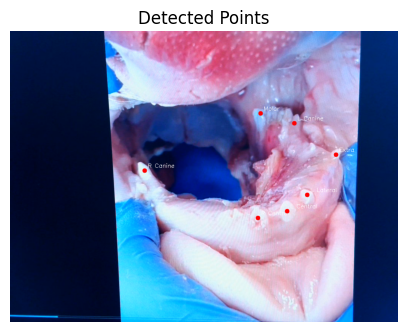

In [3]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

model_path = r"C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\runs\detect\yolo_custom_model_12\weights\best.pt"
model = YOLO(model_path)

# === Class mapping ===
class_names = {
    0: "R Canine",
    1: "R Lateral",
    2: "R Central",
    3: "L Central",
    4: "L Lateral",
    5: "Extra",
    6: "L Canine",
    7: "Molar"
}

# === Capture from webcam ===
cap = cv2.VideoCapture(1)
print("Press 'c' to capture a frame.")
print("Press 'q' to quit without saving.")

frame = None
while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    cv2.imshow("Live Feed", frame)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('c'):
        save_path = r"C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\first_frame_from_video.png"
        cv2.imwrite(save_path, frame)
        print(f"Frame saved to: {save_path}")
        break
    elif key == ord('q'):
        print("Quit without saving.")
        cap.release()
        cv2.destroyAllWindows()
        exit()

cap.release()
cv2.destroyAllWindows()

# === Use captured frame for annotation ===
annotated_frame = frame.copy()

# === Apply YOLO on captured frame ===
results = model(frame)[0]

# === Initialize centers dictionary ===
centers = {
    "R Canine": None, "R Lateral": None, "R Central": None,
    "L Central": None, "L Lateral": None, "Extra": None,
    "L Canine": None, "Molar": None
}

# === Extract and store center coordinates ===
for box in results.boxes:
    cls_id = int(box.cls.item())
    class_name = class_names.get(cls_id, "Unknown")
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)

    if class_name in centers:
        centers[class_name] = (cx, cy)

# === Draw detections ===
for label, coord in centers.items():
    if coord is not None:
        cv2.circle(annotated_frame, coord, radius=6, color=(0, 0, 255), thickness=-1)
        cv2.putText(annotated_frame, label, (coord[0] + 8, coord[1] - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# === Show and save annotated frame ===
cv2.imshow("Detected Points", annotated_frame)
cv2.imwrite("annotated_frame_with_points.png", annotated_frame)
cv2.waitKey(0)
cv2.destroyAllWindows()

# === Save coordinates for later use ===
pts2 = []
for label in centers:
    if centers[label] is not None:
        pts2.append(centers[label])
        print(f"{label} detected")
    else:
        print(f"[WARNING] {label} was not detected.")

np.save("video_detected_points.npy", np.array(pts2, dtype=np.float32))
print(f"[INFO] Saved {len(pts2)} video points to 'video_detected_points.npy'")

# === Show with matplotlib (optional) ===
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Detected Points")
plt.show()

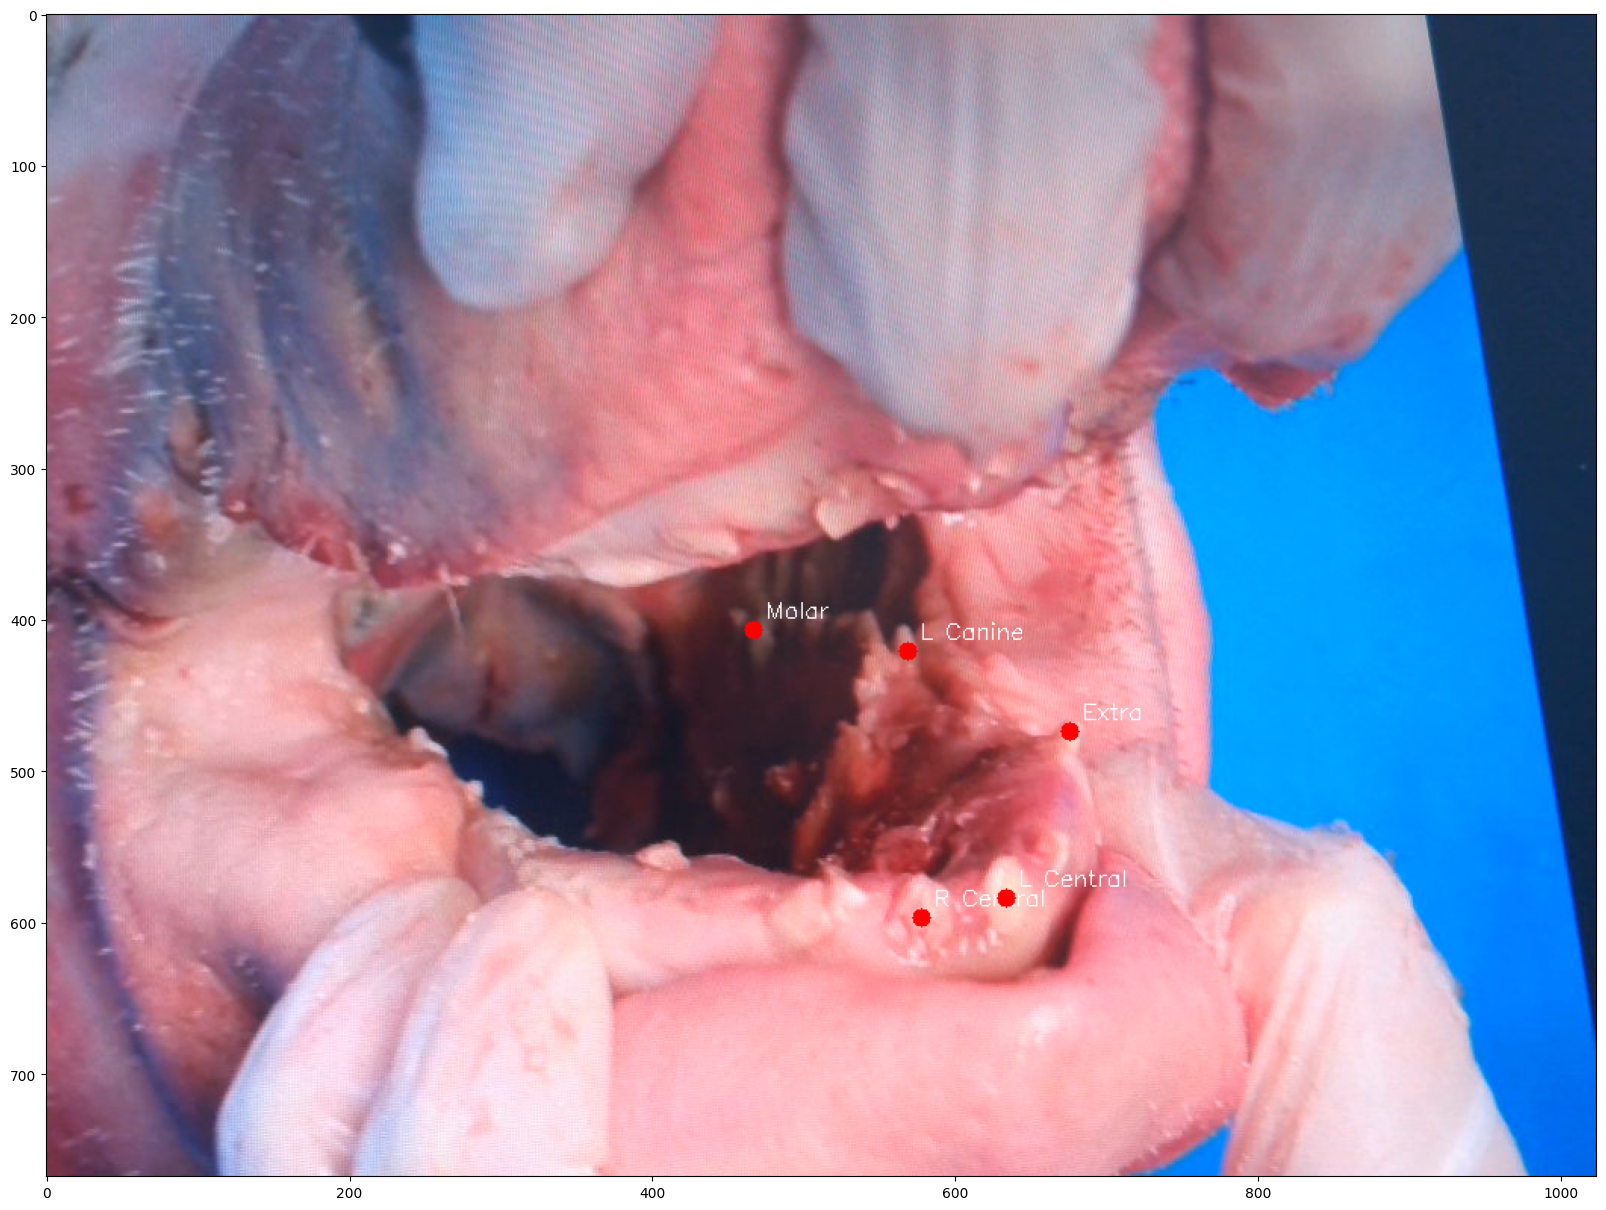

In [8]:
plt.figure(figsize = (20,20))
gray_img = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
plt.imshow(gray_img, cmap='gray')


Select 6 points on Image 1...


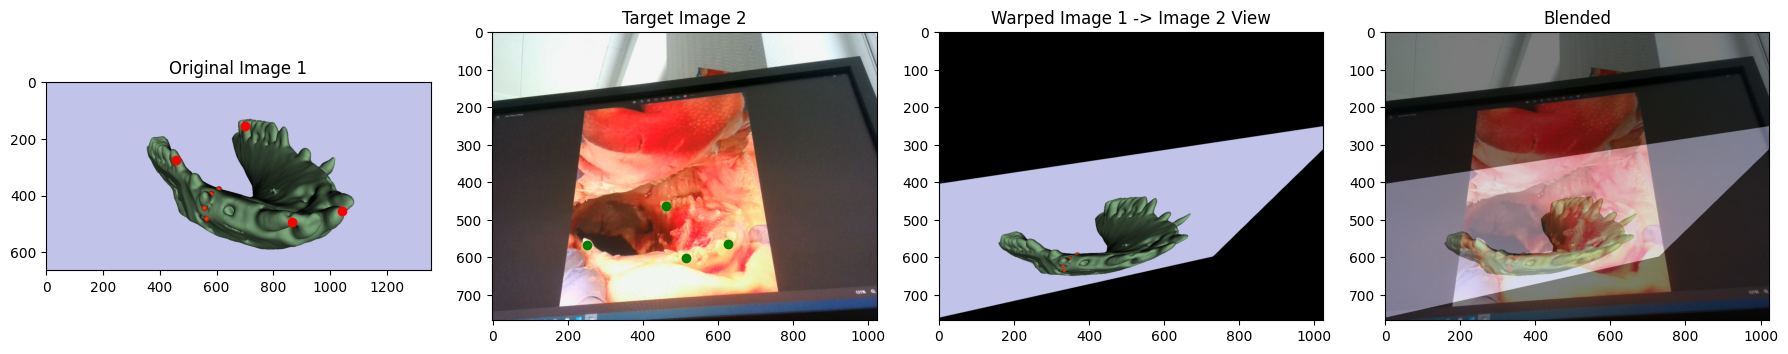

In [40]:

import matplotlib.pyplot as plt

def click_event_img1(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(points_img1) < 15:
        points_img1.append([x, y])

        cv2.circle(scan_display, (x, y), 5, (0, 255, 0), -1)
        
        cv2.imshow("Image 1 - Select 6 points", scan_display)


# Global variables to store clicked points
points_img1 = []

def transparency(ct, video, percentage_ct = 0.5, percentage_video = 0.5):
    
    scan_float = ct.astype(float) / 255.0
    video_float = video.astype(float) / 255.0
    scan_transparent = percentage_ct * scan_float
    video_transparent = percentage_video * video_float

    blended = scan_transparent + video_transparent
    blended = np.clip(blended, 0, 1)

    blended_uint8 = (blended * 255).astype(np.uint8)
    
    cv2.imshow("Blended Image", blended_uint8)

    cv2.waitKey(0)
    
    
    cv2.destroyAllWindows()
    cv2.imwrite("Overlay.png", blended_uint8)
    return blended_uint8




scan = cv2.imread(r"C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\CT_images\ct5.png")

cv2.imwrite("F.png", scan)
video = cv2.imread(r"C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\first_frame_from_video.png")
cv2.imwrite("Frame.png", video)



save_h_path = "initial_homography.npy"

scale = 0.5  # Set this based on your screen size


# === DISPLAY IMAGES SCALED FOR POINT SELECTION ===
scan_display = cv2.resize(scan.copy(), (
    int(scan.shape[1] * scale),
    int(scan.shape[0] * scale)
))
video_display = cv2.resize(video.copy(), (
    int(video.shape[1] * scale),
    int(video.shape[0] * scale)
))


# === SELECT POINTS ON IMAGE 1 ===

cv2.imshow("Image 1 - Select 6 points", scan_display)
cv2.setMouseCallback("Image 1 - Select 6 points", click_event_img1)
print("Select 6 points on Image 1...")
cv2.waitKey(0)
cv2.destroyWindow("Image 1 - Select 6 points")
pts1 = np.float32(points_img1) / scale
pts2 = np.load("video_detected_points.npy").astype(np.float32)


# === COMPUTE HOMOGRAPHY & WARP ===
matrix, status = cv2.findHomography(pts1, pts2)
np.save(save_h_path, matrix)
warped_scan = cv2.warpPerspective(scan, matrix, (video.shape[1], video.shape[0]))

# === CONVERT TO RGB FOR PLOTTING ===
scan_rgb = cv2.cvtColor(scan, cv2.COLOR_BGR2RGB)
video_rgb = cv2.cvtColor(video, cv2.COLOR_BGR2RGB)
warped_rgb = cv2.cvtColor(warped_scan, cv2.COLOR_BGR2RGB)

# === TRANSPARENCY BLENDING ===
def transparency(scan_img, video_img, alpha_ct=0.5, alpha_video=0.5):
    scan_float = scan_img.astype(np.float32) / 255.0
    video_float = video_img.astype(np.float32) / 255.0
    blended = alpha_ct * scan_float + alpha_video * video_float
    blended = np.clip(blended, 0, 1)
    return (blended * 255).astype(np.uint8)

blend = transparency(warped_rgb, video_rgb, 0.5, 0.5)

# === PLOT RESULTS ===
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(scan_rgb)
plt.title("Original Image 1")
for pt in pts1:
    plt.plot(pt[0], pt[1], 'ro')

plt.subplot(1, 4, 2)
plt.imshow(video_rgb)
plt.title("Target Image 2")
for pt in pts2:
    plt.plot(pt[0], pt[1], 'go')

plt.subplot(1, 4, 3)
plt.imshow(warped_rgb)

plt.title("Warped Image 1 -> Image 2 View")

plt.subplot(1, 4, 4)
plt.imshow(blend)
plt.title("Blended")




plt.tight_layout()
plt.show()

In [1]:

cv2.imshow("Blend", blend)

cv2.waitKey(0)
cv2.destroyAllWindows()


NameError: name 'cv2' is not defined

In [42]:
import cv2
import numpy as np

# === CONFIGURATION ===
ct_image_path = r"C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\CT_images\ct5.png"
save_h_path = r'initial_homography.npy'
output_path = r"C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\tracked_overlay_line.avi"


# === INIT VIDEO ===
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    raise IOError("Cannot open webcam")

print("Press 'c' to capture the frame with the CT overlay.")
print("Press 'q' to quit.")

cap_frame = None
while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    cv2.imshow("Live Feed - Press 'c' to capture", frame)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('c'):
        cap_frame = frame.copy()
        print("Captured frame for CT overlay and tracking.")
        break
    elif key == ord('q'):
        print("Exiting without capturing.")
        cap.release()
        cv2.destroyAllWindows()
        exit()

cv2.destroyWindow("Live Feed - Press 'c' to capture")

if cap_frame is None:
    raise IOError("No frame was captured.")


# === Load CT image and homography ===
initial_ct = cv2.imread(ct_image_path)
H_ct_to_0 = np.load(save_h_path)

# === Warp CT onto first frame ===
warped_ct = cv2.warpPerspective(initial_ct, H_ct_to_0, (cap_frame.shape[1], cap_frame.shape[0]))
mask = cv2.cvtColor(warped_ct, cv2.COLOR_BGR2GRAY) > 10
mask_3ch = cv2.merge([mask.astype(np.uint8)] * 3)

alpha = 0.3
overlay = cap_frame.copy()
overlay[mask_3ch == 1] = cv2.addWeighted(cap_frame, 1 - alpha, warped_ct, alpha, 0)[mask_3ch == 1]

# === Interactive line drawing ===
line_points = []
def draw_line_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(line_points) < 10:
        line_points.append([x, y])
        cv2.circle(param, (x, y), 4, (0, 255, 255), -1)
        if len(line_points) > 1:
            cv2.polylines(param, [np.array(line_points)], isClosed=False, color=(0, 255, 0), thickness=2)
        cv2.imshow("Draw Line to Track", param)

clone = overlay.copy()
cv2.namedWindow("Draw Line to Track")
cv2.setMouseCallback("Draw Line to Track", draw_line_event, clone)
print("Draw 4–10 points to define a line. Press ENTER to continue.")

while True:
    temp = clone.copy()
    if len(line_points) >= 2:
        cv2.polylines(temp, [np.array(line_points)], isClosed=False, color=(0, 255, 0), thickness=2)
    cv2.imshow("Draw Line to Track", temp)
    key = cv2.waitKey(10) & 0xFF
    if key == 13 or key == 10:  # Enter
        break
    elif key == 27:  # ESC
        print("Canceled. Exiting.")
        cap.release()
        cv2.destroyAllWindows()
        exit()

cv2.destroyWindow("Draw Line to Track")

# === Prepare tracking ===
prev_gray = cv2.cvtColor(cap_frame, cv2.COLOR_BGR2GRAY)
points_to_track = np.array(line_points, dtype=np.float32).reshape(-1, 1, 2)

# === Prepare video writer ===
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 10
fourcc = cv2.VideoWriter_fourcc(*'XVID')
video_writer = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

# === Start tracking ===
while True:
    ret, curr_frame = cap.read()
    if not ret:
        break

    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
    new_points, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, points_to_track, None)

    if new_points is not None and status is not None:
        valid_new = new_points[status.flatten() == 1]
        if len(valid_new) >= 2:
            updated_points = valid_new.reshape(-1, 2).astype(np.int32)
            cv2.polylines(curr_frame, [updated_points], isClosed=False, color=(0, 255, 0), thickness=2)
            points_to_track = valid_new.reshape(-1, 1, 2)

    cv2.imshow("Tracked Curve", curr_frame)
    video_writer.write(curr_frame)

    key = cv2.waitKey(10) & 0xFF
    
    if key == 27 or key == ord('q'):
        print("Exiting.")
        
        break

    prev_gray = curr_gray.copy()

cap.release()
video_writer.release()
cv2.destroyAllWindows()
print(f"[INFO] Video saved to: {output_path}")


Press 'c' to capture the frame with the CT overlay.
Press 'q' to quit.
Captured frame for CT overlay and tracking.
Draw 4–10 points to define a line. Press ENTER to continue.
Exiting.
[INFO] Video saved to: C:\Users\Anwari Ahmed\Desktop\Internship\AR_Mandible\tracked_overlay_line.avi
